10011


In [2]:
import pandas as pd

gbm = pd.read_csv('../data/processed/diff/CPTAC_combined.csv')
corr = gbm["log2FC_rna"].corr(gbm["log2FC_prot"])
print(f"Pearson correlation = {corr:.3f}")
print(f"Squared Pearson correlation = {corr**2:.3f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=gbm,
    x="log2FC_rna",
    y="log2FC_prot",
    alpha=0.4,
    s=15
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("RNA log2FC")
plt.ylabel("Protein log2FC")
plt.title("CPTAC GBM vs Healthy: RNA vs Protein Fold Changes")

plt.tight_layout()
plt.show()



Pearson correlation = 0.710
Squared Pearson correlation = 0.503


KeyboardInterrupt: 


PRONEURAL
Pearson correlation = 0.680
Squared Pearson correlation = 0.463


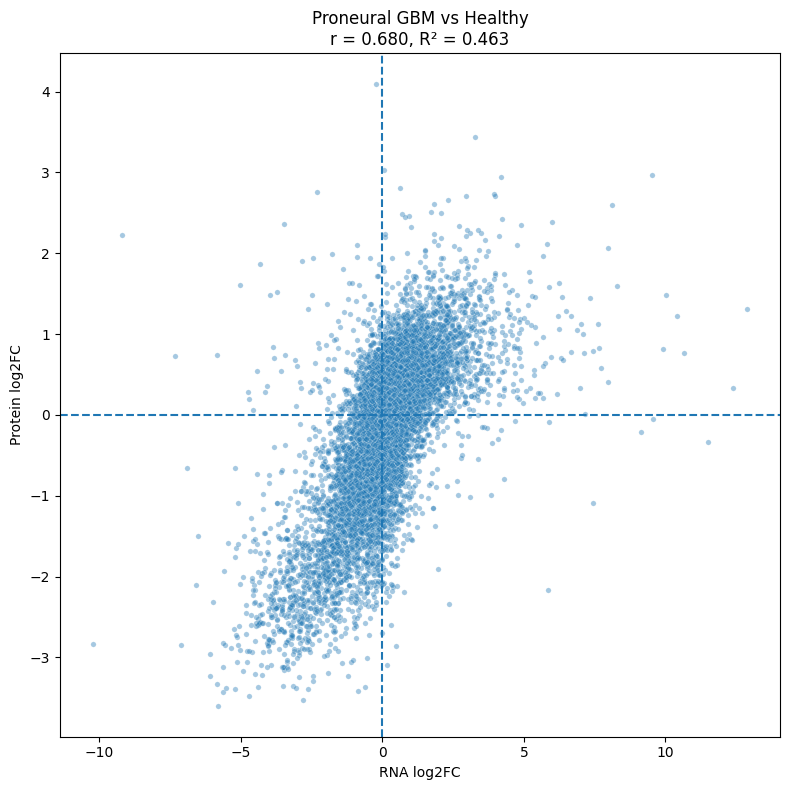


CLASSICAL
Pearson correlation = 0.660
Squared Pearson correlation = 0.436


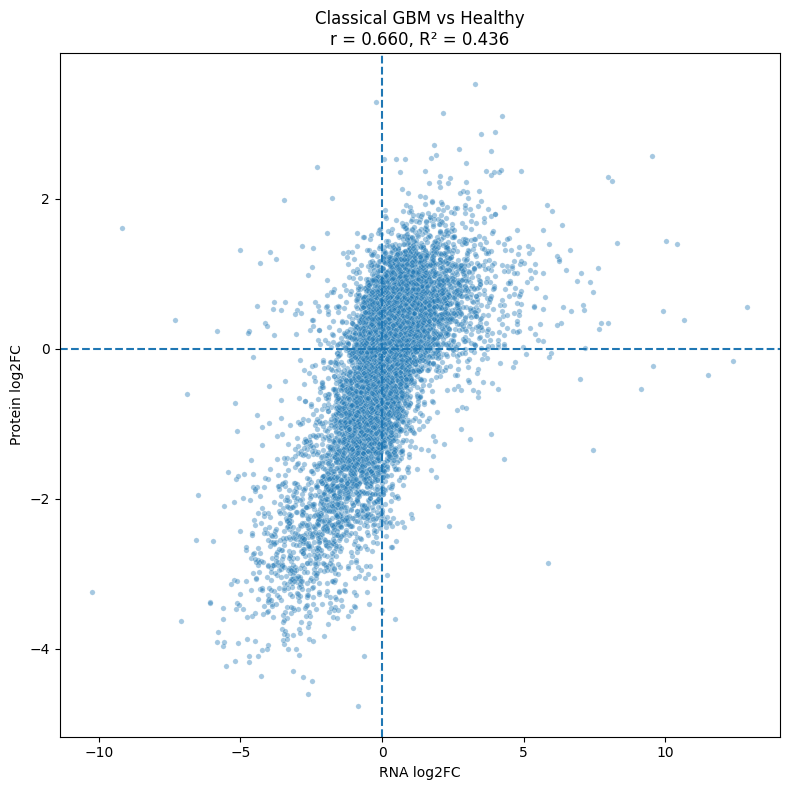


MESENCHYMAL
Pearson correlation = 0.687
Squared Pearson correlation = 0.472


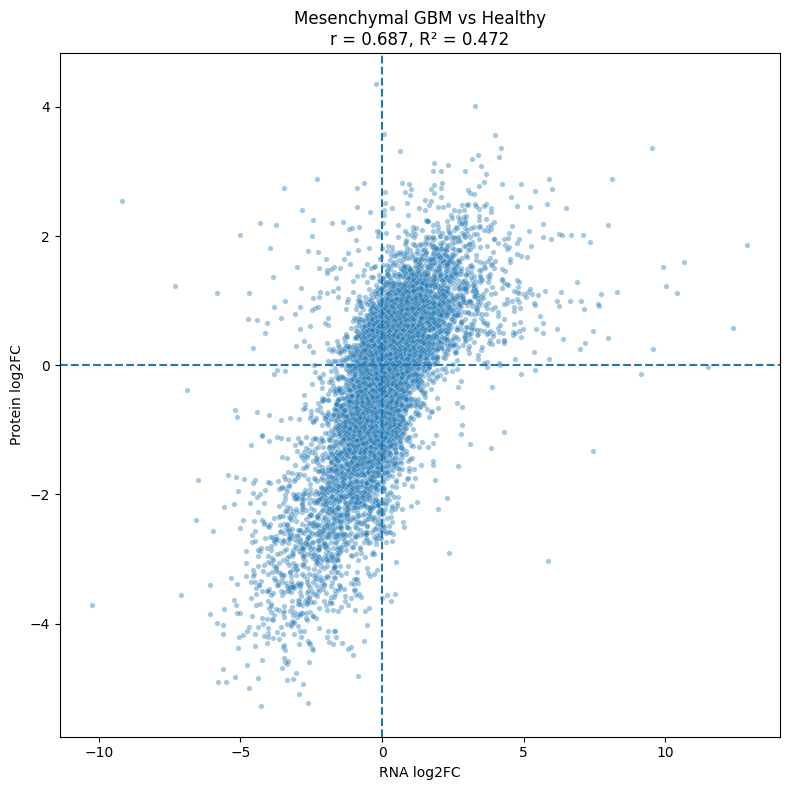


IDH
Pearson correlation = 0.646
Squared Pearson correlation = 0.417


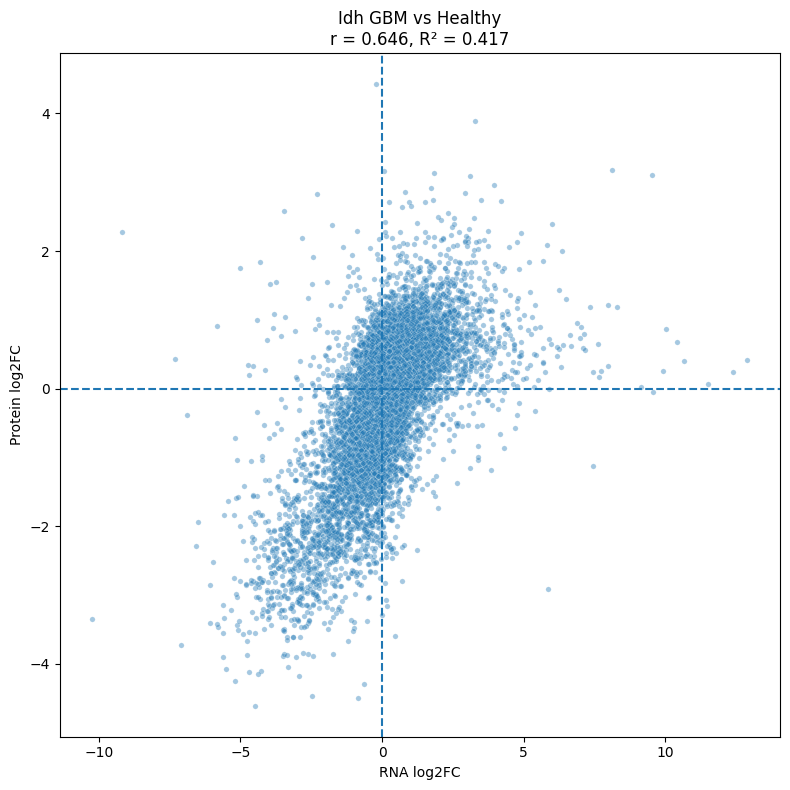

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subtypes = [
    "proneural",
    "classical",
    "mesenchymal",
    "idh"
]

for subtype in subtypes:

    df = pd.read_csv(
        f"../data/processed/{subtype}_combined.csv"
    )

    corr = df["log2FC_rna"].corr(
        df["log2FC_prot"]
    )

    print(f"\n{subtype.upper()}")
    print(f"Pearson correlation = {corr:.3f}")
    print(f"Squared Pearson correlation = {corr**2:.3f}")

    plt.figure(figsize=(8, 8))

    sns.scatterplot(
        data=df,
        x="log2FC_rna",
        y="log2FC_prot",
        alpha=0.4,
        s=15
    )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("RNA log2FC")
    plt.ylabel("Protein log2FC")
    plt.title(
        f"{subtype.capitalize()} GBM vs Healthy\n"
        f"r = {corr:.3f}, R² = {corr**2:.3f}"
    )

    plt.tight_layout()
    plt.show()

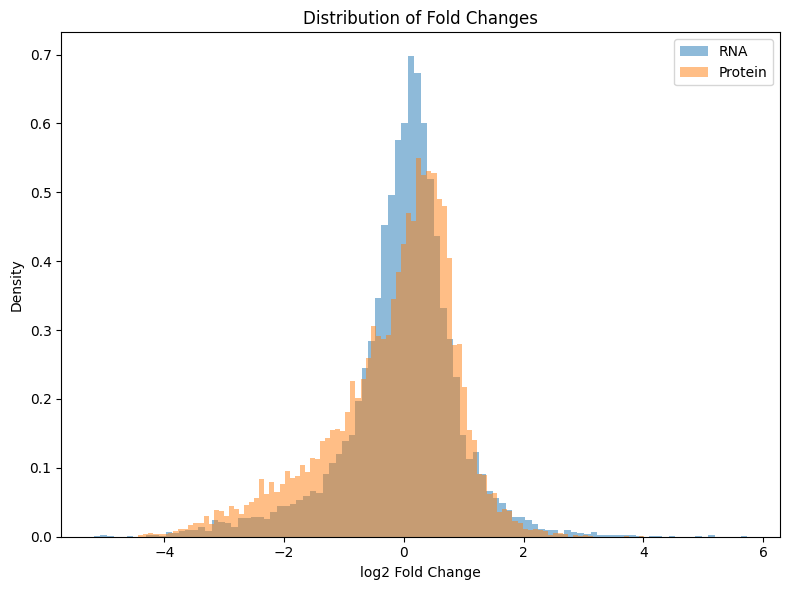

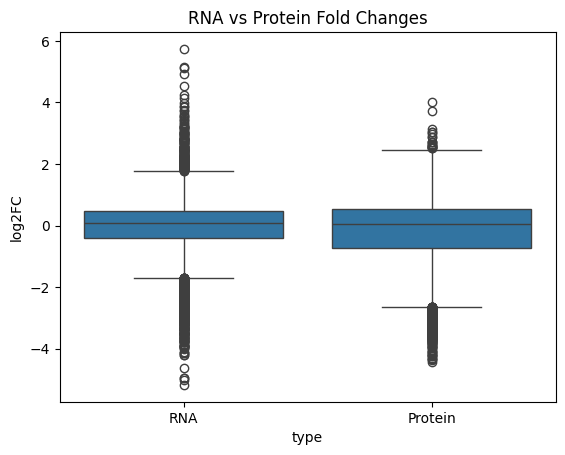

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    merged["log2FC_rna"],
    bins=100,
    alpha=0.5,
    density=True,
    label="RNA"
)

plt.hist(
    merged["log2FC_prot"],
    bins=100,
    alpha=0.5,
    density=True,
    label="Protein"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("Density")
plt.title("Distribution of Fold Changes")
plt.legend()

plt.tight_layout()
plt.show()


plot_df = pd.DataFrame({
    "value": pd.concat([
        merged["log2FC_rna"],
        merged["log2FC_prot"]
    ]),
    "type": (
        ["RNA"] * len(merged) +
        ["Protein"] * len(merged)
    )
})

sns.boxplot(data=plot_df, x="type", y="value")
plt.ylabel("log2FC")
plt.title("RNA vs Protein Fold Changes")
plt.show()

# Proteins that are the expressed the same "sign"

In [ ]:

merged2 = merged.copy()
merged2 = merged2[merged["log2FC_rna"] * merged["log2FC_prot"] > 0]

corr2 = merged2["log2FC_rna"].corr(merged2["log2FC_prot"])
print(f"Pearson correlation = {corr2:.3f}")
print(f"Squared Pearson correlation = {corr2**2:.3f}")

merged2

Pearson correlation = 0.820
Squared Pearson correlation = 0.672


,log2FC_rna,pvalue_rna,adjustedpvalue_rna,-log(adjustedp)_rna,log2FC_prot,pvalue_prot,adjustedpvalue_prot,-log(adjustedp)_prot
Gene,,,,,,,,
A2M,0.895503,2.751120e-10,1.613700e-09,8.792177,1.446368,2.631714e-14,1.480730e-13,12.829524
AAAS,1.170456,2.530039e-05,7.293219e-05,4.137081,0.603250,5.753307e-08,1.502036e-07,6.823320
AACS,-1.200968,2.777619e-10,1.627681e-09,8.788431,-0.747064,8.155613e-09,2.376589e-08,7.624046
AADAT,-0.470732,1.837089e-06,6.219132e-06,5.206270,-1.181237,7.377722e-08,1.893361e-07,6.722767
AAED1,1.235063,1.386718e-09,7.361896e-09,8.133010,0.870320,4.539880e-03,6.213755e-03,2.206646
...,...,...,...,...,...,...,...,...
ZW10,0.055366,2.488346e-01,3.258164e-01,0.487027,0.170689,1.517266e-03,2.203603e-03,2.656867
ZWILCH,0.343858,7.097133e-04,1.642846e-03,2.784403,0.940229,7.961461e-07,1.781020e-06,5.749331
ZYG11B,-0.771744,6.547534e-12,4.963860e-11,10.304181,-0.642655,5.650706e-12,2.446680e-11,10.611423


In [ ]:
merged2.to_csv("../data/processed/samesign.csv")

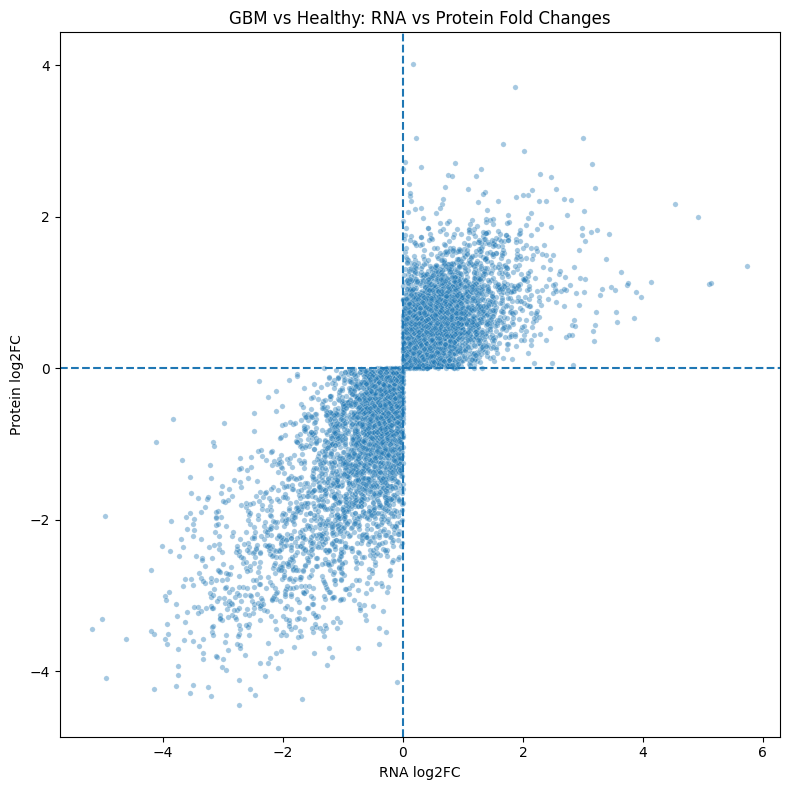

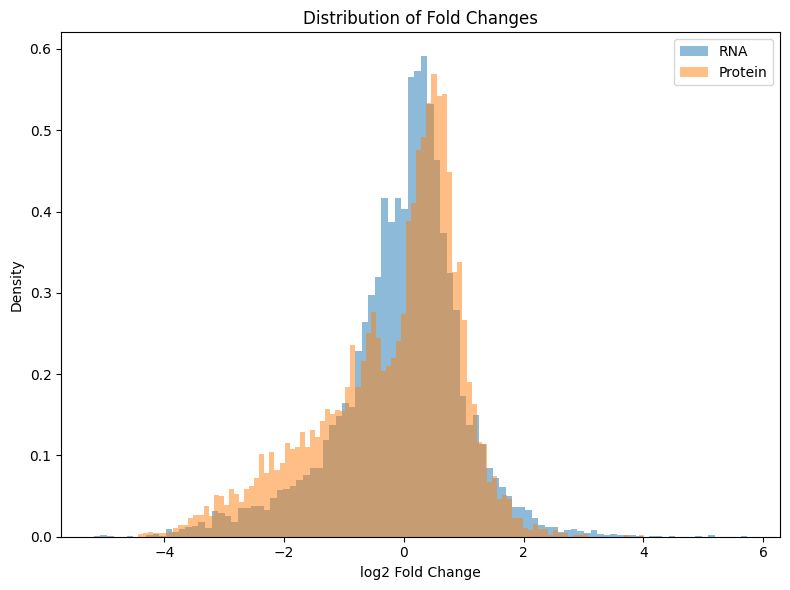

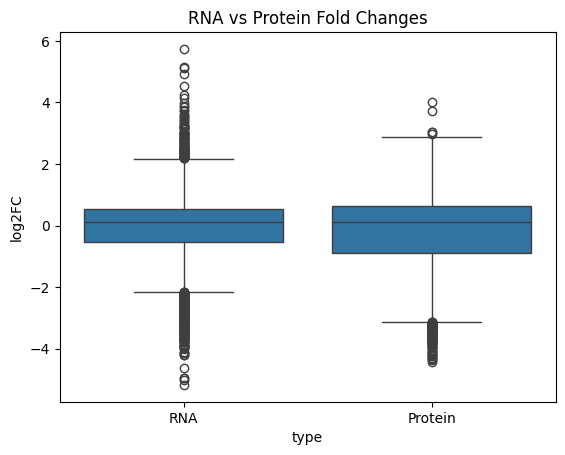

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=merged2,
    x="log2FC_rna",
    y="log2FC_prot",
    alpha=0.4,
    s=15
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("RNA log2FC")
plt.ylabel("Protein log2FC")
plt.title("GBM vs Healthy: RNA vs Protein Fold Changes")

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    merged2["log2FC_rna"],
    bins=100,
    alpha=0.5,
    density=True,
    label="RNA"
)

plt.hist(
    merged2["log2FC_prot"],
    bins=100,
    alpha=0.5,
    density=True,
    label="Protein"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("Density")
plt.title("Distribution of Fold Changes")
plt.legend()

plt.tight_layout()
plt.show()


plot_df = pd.DataFrame({
    "value": pd.concat([
        merged2["log2FC_rna"],
        merged2["log2FC_prot"]
    ]),
    "type": (
        ["RNA"] * len(merged2) +
        ["Protein"] * len(merged2)
    )
})

sns.boxplot(data=plot_df, x="type", y="value")
plt.ylabel("log2FC")
plt.title("RNA vs Protein Fold Changes")
plt.show()

